# Double Gyre — Barotropic QG

The wind-driven **double gyre** is the canonical wind-forced ocean-basin test:
a sinusoidal wind-stress curl spins up two counter-rotating gyres, the
$\beta$-effect concentrates the return flow into a narrow **western boundary
current**, and — at low enough viscosity — that current goes barotropically
unstable into a **meandering eastward jet that sheds eddies** (geostrophic
turbulence).

**Barotropic quasi-geostrophic** is the cheapest model that captures it: a
single potential-vorticity field, advected by the energy- and
enstrophy-conserving **Arakawa Jacobian** and inverted to a streamfunction
with a spectral Poisson solve. The enstrophy-conserving advection is what lets
the run stay stable in the turbulent (eddy-permitting) regime even though the
grid-Reynolds number is well above the centred-advection limit.

This page **executes a 64² turbulent run** (cheap, ~minutes) and then gives
**ready-to-run, correctly-scaled commands for 128²–1024²** that you can launch
in your own time (256²+ wants a GPU). It follows the repo's
[`getting-sims-to-work`](https://github.com/jejjohnson/somax/blob/main/.github/skills/getting-sims-to-work/SKILL.md)
methodology throughout: observability first, probe cost before committing, and
scale forcing/viscosity/`dt` with the resolution.

In [1]:
import time

import diffrax as dfx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from finitevolx import Difference2D

from somax.models import BarotropicQG, BarotropicQGState

# Fixed physics for the whole resolution sweep: a 1000 km square basin, a
# mid-latitude beta-plane, a double-gyre wind, and linear bottom drag. Only the
# numerics (viscosity and dt) change with resolution.
LX = LY = 1.0e6
F0, BETA = 1.0e-4, 1.6e-11
WIND = 2.0e-11  # wind-stress-curl amplitude (turbulent regime)
DRAG = 1.0e-7  # linear bottom drag (1/s)
NU0_AT_64 = 150.0  # lateral viscosity at 64^2; scaled down with dx below


def build_model(nx: int) -> BarotropicQG:
    """Barotropic-QG double gyre at resolution ``nx`` with resolution-scaled ν.

    The physics (domain, beta, wind, drag) is fixed; the lateral viscosity is
    scaled **linearly with the grid spacing**, ``ν = 150·(64/nx)``, so the
    grid-Reynolds number stays in the same eddy-resolving band as resolution
    increases (finer grids resolve smaller eddies, so they need — and tolerate —
    less viscosity). At every resolution this stays at/below the Munk-layer
    viscosity, i.e. deliberately eddy-permitting.
    """
    nu = NU0_AT_64 * (64.0 / nx)
    return BarotropicQG.create(
        nx=nx,
        ny=nx,
        Lx=LX,
        Ly=LY,
        f0=F0,
        beta=BETA,
        lateral_viscosity=nu,
        bottom_drag=DRAG,
        wind_amplitude=WIND,
        wind_profile="doublegyre",
    )


def recommended_dt(nx: int) -> float:
    """Starting `dt` (s), scaled from the 64² value by the advective CFL.

    The jet speed grows as the grid sharpens, so `dt` must shrink. `dt ∝ dx`
    (``600·(64/nx)``) is a safe first guess; confirm it with :func:`probe`,
    which reports ``|u|_max`` and the implied CFL-limited `dt`.
    """
    return 600.0 * (64.0 / nx)

## Observability + start-small helpers

`probe` runs a short window and reports the two numbers that decide whether a
long run is worth launching: **ms/step** (so you can extrapolate the cost) and
**`|u|_max`** (so you can check the advective CFL `dt < dx/|u|`). `run` does
the full integration, checks finiteness, and **saves the arrays to disk before
any plotting** so a plotting bug can never waste the integration.

In [2]:
def probe(nx: int, days: float = 180.0) -> None:
    """Short smoke + cost/CFL probe — run this BEFORE any long integration."""
    model = build_model(nx)
    s0 = BarotropicQGState(q=jnp.zeros((model.grid.Ny, model.grid.Nx)))
    dt = recommended_dt(nx)
    t1 = days * 86400.0
    t = time.time()
    sol = model.integrate(
        s0,
        t0=0.0,
        t1=t1,
        dt=dt,
        saveat=dfx.SaveAt(ts=jnp.array([t1])),
        max_steps=20_000_000,
    )
    jax.block_until_ready(sol.ys.q)
    el = time.time() - t
    n = int(t1 / dt)
    psi = np.asarray(model._invert_pv(sol.ys.q[-1]))[2:-2, 2:-2]
    u = -np.gradient(psi, model.grid.dy, axis=0)
    v = np.gradient(psi, model.grid.dx, axis=1)
    umax = float(np.sqrt(u**2 + v**2).max())
    finite = bool(jnp.all(jnp.isfinite(sol.ys.q)))
    print(
        f"{nx:>4}²  dx={model.grid.dx / 1e3:5.1f} km  ν={model.params.lateral_viscosity:6.1f}"
        f"  dt={dt:6.0f}s  {el / n * 1e3:6.2f} ms/step  finite={finite}"
        f"  |u|max={umax:5.2f} m/s  CFL-dt≈{0.4 * model.grid.dx / max(umax, 1e-6):5.0f}s"
    )


def run(nx: int, years: float, dt: float | None = None, save: str | None = None):
    """Full spin-up; finiteness-checked; arrays saved before plotting."""
    model = build_model(nx)
    s0 = BarotropicQGState(q=jnp.zeros((model.grid.Ny, model.grid.Nx)))
    dt = recommended_dt(nx) if dt is None else dt
    t1 = years * 31557600.0
    sol = model.integrate(
        s0,
        t0=0.0,
        t1=t1,
        dt=dt,
        saveat=dfx.SaveAt(ts=jnp.array([t1])),
        max_steps=50_000_000,
    )
    jax.block_until_ready(sol.ys.q)
    q = sol.ys.q[-1]
    assert bool(jnp.all(jnp.isfinite(q))), "non-finite — drop dt or raise ν"
    diff = Difference2D(grid=model.grid)
    psi_f = np.asarray(model._invert_pv(q))
    zeta_f = np.asarray(
        diff.curl(
            -diff.diff_y_T_to_V(jnp.asarray(psi_f)),
            diff.diff_x_T_to_U(jnp.asarray(psi_f)),
        )
    )
    psi = psi_f[2:-2, 2:-2]
    zeta = zeta_f[2:-2, 2:-2]
    u = -np.gradient(psi, model.grid.dy, axis=0)
    v = np.gradient(psi, model.grid.dx, axis=1)
    ke = 0.5 * (u**2 + v**2)
    x = np.asarray(jnp.arange(model.grid.Nx) * model.grid.dx)[2:-2] / 1e3
    y = np.asarray(jnp.arange(model.grid.Ny) * model.grid.dy)[2:-2] / 1e3
    if save is not None:  # checkpoint BEFORE plotting
        np.savez(save, psi=psi, ke=ke, zeta=zeta, x=x, y=y)
    diag = model.diagnose(BarotropicQGState(q=q))
    print(
        f"{nx}²  {years:g} yr  KE={float(diag.kinetic_energy):.3e}"
        f"  enstrophy={float(diag.enstrophy):.3e}  |u|max={float(np.sqrt(u**2 + v**2).max()):.2f} m/s"
    )
    return x, y, psi, ke, zeta

## Executed run — 64², turbulent (3 yr)

Low viscosity (`ν=150`) and a moderate wind (`2e-11`) put this in the
eddy-permitting regime; the boundary current destabilises into a meandering
jet within the first year or two.

In [3]:
x, y, psi, ke, zeta = run(nx=64, years=3.0, dt=600.0)

64²  3 yr  KE=1.601e+13  enstrophy=7.932e+02  |u|max=10.57 m/s


## Streamfunction, kinetic energy, and the eddy field

$\psi$ (the gyres + boundary current), kinetic energy
$\tfrac{1}{2}(u^2+v^2)$ (lights up the jet and eddies), and relative
vorticity $\zeta$ (the clearest view of the turbulent eddy field).

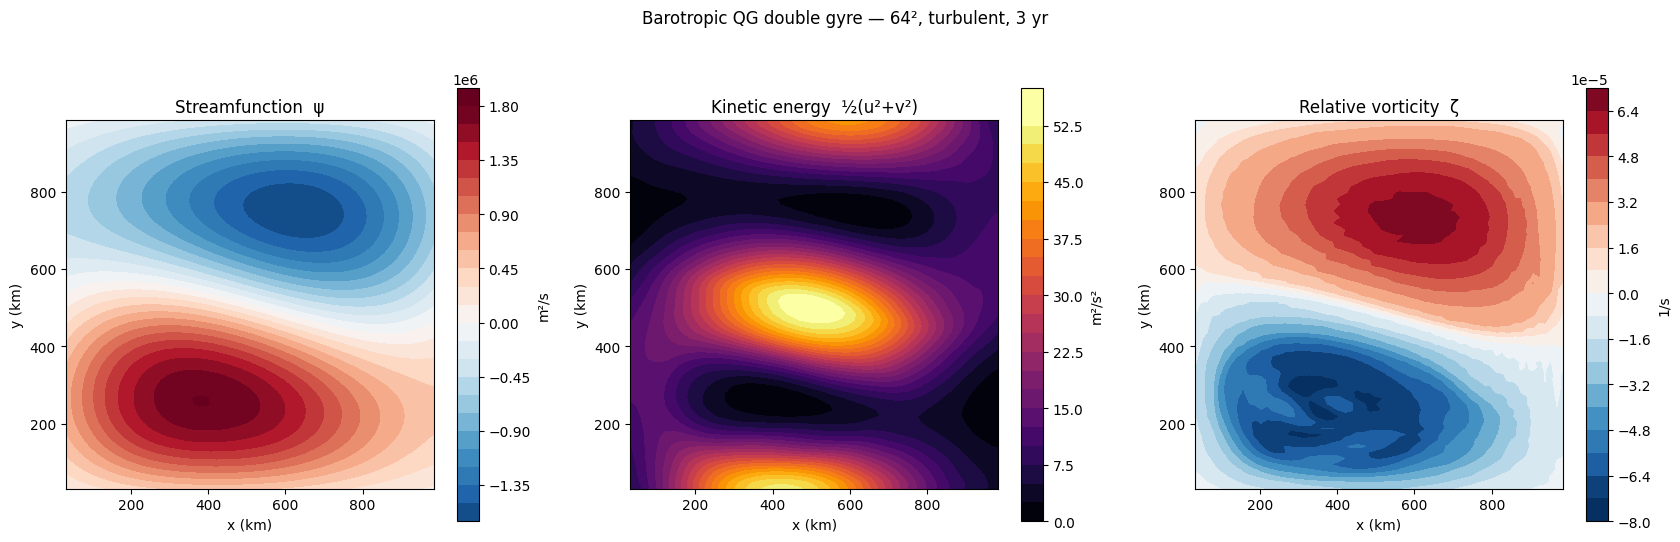

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5.2))
mp = np.percentile(np.abs(psi), 99.5) or 1.0
c0 = axes[0].contourf(x, y, psi, levels=23, cmap="RdBu_r", vmin=-mp, vmax=mp)
axes[0].set_title("Streamfunction  ψ")
plt.colorbar(c0, ax=axes[0], label="m²/s")
c1 = axes[1].contourf(
    x, y, ke, levels=23, cmap="inferno", vmin=0.0, vmax=np.percentile(ke, 99.5) or 1.0
)
axes[1].set_title("Kinetic energy  ½(u²+v²)")
plt.colorbar(c1, ax=axes[1], label="m²/s²")
mz = np.percentile(np.abs(zeta), 99.0) or 1.0
c2 = axes[2].contourf(x, y, zeta, levels=23, cmap="RdBu_r", vmin=-mz, vmax=mz)
axes[2].set_title("Relative vorticity  ζ")
plt.colorbar(c2, ax=axes[2], label="1/s")
for ax in axes:
    ax.set_xlabel("x (km)")
    ax.set_ylabel("y (km)")
    ax.set_aspect("equal")
fig.suptitle("Barotropic QG double gyre — 64², turbulent, 3 yr", y=1.03)
plt.tight_layout()
plt.show()

## Scaling up — 128², 256², 512², 1024² (run in your spare time)

The helpers above already encode the scaling, so a higher-resolution sweep is
a one-liner. **Always `probe` first**, then launch the full `run`. The finer
the grid the more of the turbulent cascade you resolve (sharper jet, more
eddies, filaments) — and the more it costs.

| nx   | dx     | ν (=150·64/nx) | dt (start) | rough cost, 10 yr, CPU\* |
|------|--------|----------------|------------|--------------------------|
| 64   | 15.6 km| 150            | 600 s      | minutes                  |
| 128  | 7.8 km | 75             | 300 s      | ~1 hr                    |
| 256  | 3.9 km | 37.5           | 150 s      | ~8 hr (use a GPU)        |
| 512  | 2.0 km | 18.75          | 75 s       | days (GPU)               |
| 1024 | 1.0 km | 9.375          | 37.5 s     | ~1 week (GPU)            |

\*Cost grows roughly as `nx³` (the grid is `nx²` and `dt ∝ 1/nx`); a GPU is
strongly recommended at 256² and above. JAX runs the same code on GPU
unchanged — just install a CUDA `jaxlib`.

```python
# 1) Probe every resolution first (ms/step, |u|max, CFL-limited dt):
for nx in (128, 256, 512, 1024):
    probe(nx)

# 2) Launch a full turbulent spin-up at the resolution you want, checkpointing
#    the fields to disk (re-plot from the .npz, never re-integrate):
x, y, psi, ke, zeta = run(nx=256, years=10.0, save="dg_bt_256.npz")

# If probe() reports the suggested CFL-dt is below recommended_dt(nx), pass it
# explicitly, e.g. run(nx=256, years=10.0, dt=120.0, save="dg_bt_256.npz").
```

Then plot from the saved arrays with the same three-panel code as above:

```python
d = np.load("dg_bt_256.npz")
x, y, psi, ke, zeta = d["x"], d["y"], d["psi"], d["ke"], d["zeta"]
# ... same contourf panels ...
```

## Notes

- **Resolution ↔ forcing ↔ viscosity ↔ `dt` are coupled.** Here the physics
  (wind, drag, domain, β) is held fixed and only ν and `dt` scale with the
  grid: ν shrinks ∝ `dx` to stay eddy-resolving, and `dt` shrinks because the
  sharper jet tightens the advective CFL `dt < dx/|u|`.
- **QG removes the external gravity-wave CFL** (no `√(gH)` term), so `dt` is
  set by advection, not waves.
- Stability in this high-grid-Reynolds regime comes from the
  **enstrophy-conserving Arakawa Jacobian** + bottom drag, not from viscosity.
- See the
  [`getting-sims-to-work`](https://github.com/jejjohnson/somax/blob/main/.github/skills/getting-sims-to-work/SKILL.md)
  skill for the full bring-up checklist.